In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

In [2]:
data = pd.read_csv("sunting_jabar.csv")
df = pd.DataFrame(data)

df.head(10)

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,persentase_balita_stunting,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,9.04,PERSEN,2014
1,2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,12.21,PERSEN,2014
2,3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,14.33,PERSEN,2014
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,17.14,PERSEN,2014
4,5,32,JAWA BARAT,3205,KABUPATEN GARUT,7.12,PERSEN,2014
5,6,32,JAWA BARAT,3206,KABUPATEN TASIKMALAYA,23.8,PERSEN,2014
6,7,32,JAWA BARAT,3207,KABUPATEN CIAMIS,5.12,PERSEN,2014
7,8,32,JAWA BARAT,3208,KABUPATEN KUNINGAN,7.52,PERSEN,2014
8,9,32,JAWA BARAT,3209,KABUPATEN CIREBON,12.94,PERSEN,2014
9,10,32,JAWA BARAT,3210,KABUPATEN MAJALENGKA,10.43,PERSEN,2014


In [3]:
df.shape

(297, 8)

In [4]:
df.info()
df.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   id                          297 non-null    int64
 1   kode_provinsi               297 non-null    int64
 2   nama_provinsi               297 non-null    str  
 3   kode_kabupaten_kota         297 non-null    int64
 4   nama_kabupaten_kota         297 non-null    str  
 5   persentase_balita_stunting  297 non-null    str  
 6   satuan                      297 non-null    str  
 7   tahun                       297 non-null    int64
dtypes: int64(4), str(4)
memory usage: 18.7 KB


,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,persentase_balita_stunting,satuan,tahun
count,297.000000,297.0,297,297.000000,297,297,297,297.000000
unique,NaN,NaN,1,NaN,27,272,1,NaN
top,NaN,NaN,JAWA BARAT,NaN,KABUPATEN BOGOR,13.42,PERSEN,NaN
freq,NaN,NaN,297,NaN,11,3,297,NaN
mean,149.000000,32.0,NaN,3231.333333,NaN,NaN,NaN,2019.000000
std,85.880731,0.0,NaN,31.254513,NaN,NaN,NaN,3.167615
min,1.000000,32.0,NaN,3201.000000,NaN,NaN,NaN,2014.000000
25%,75.000000,32.0,NaN,3207.000000,NaN,NaN,NaN,2016.000000
50%,149.000000,32.0,NaN,3214.000000,NaN,NaN,NaN,2019.000000
75%,223.000000,32.0,NaN,3273.000000,NaN,NaN,NaN,2022.000000


Mengubah persentase_balita_stunting dari str ke float

In [5]:
df["persentase_balita_stunting"].unique()[:10]

<StringArray>
[ '9.04', '12.21', '14.33', '17.14',  '7.12',  '23.8',  '5.12',  '7.52',
 '12.94', '10.43']
Length: 10, dtype: str

In [6]:
df["persentase_balita_stunting"] = (
    df["persentase_balita_stunting"]
    .str.replace("%", "", regex=False)
    .str.replace(",", ".", regex=False)
    .astype(float)
)

Pengelompokan balita di setiap kota/kabupaten dari terbesar ke kecil

In [7]:
df.groupby("nama_kabupaten_kota")["persentase_balita_stunting"].mean().sort_values(
    ascending=False
)

nama_kabupaten_kota
KABUPATEN TASIKMALAYA      15.263636
KOTA CIREBON               12.530000
KOTA TASIKMALAYA           12.117273
KABUPATEN INDRAMAYU        11.666364
KOTA CIMAHI                10.897273
KABUPATEN CIREBON          10.175455
KABUPATEN BANDUNG           9.646364
KABUPATEN SUMEDANG          9.390909
KABUPATEN BANDUNG BARAT     9.160000
KABUPATEN GARUT             8.971818
KABUPATEN SUKABUMI          8.723636
KOTA BEKASI                 8.550909
KABUPATEN CIANJUR           8.146364
KABUPATEN KARAWANG          8.056364
KOTA SUKABUMI               7.709091
KOTA BANDUNG                7.603636
KOTA BANJAR                 7.555455
KABUPATEN KUNINGAN          7.327273
KOTA DEPOK                  7.239091
KABUPATEN PURWAKARTA        6.672727
KABUPATEN PANGANDARAN       6.308182
KOTA BOGOR                  5.940909
KABUPATEN CIAMIS            5.913636
KABUPATEN BOGOR             5.740909
KABUPATEN BEKASI            4.522727
KABUPATEN MAJALENGKA        4.392727
KABUPATEN SUBANG  

Melihat distribusi data dan outlier (nilai ekstrem)

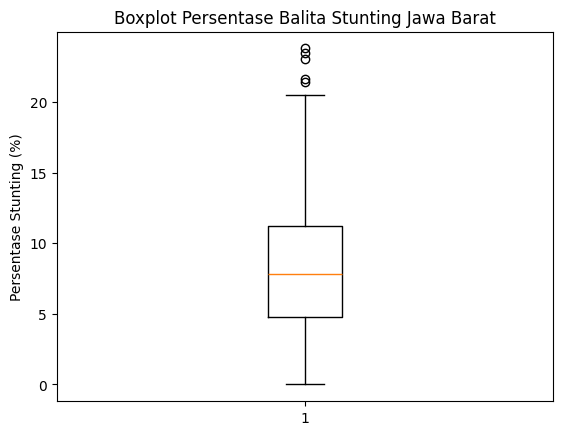

In [8]:
plt.boxplot(df["persentase_balita_stunting"])
plt.title("Boxplot Persentase Balita Stunting Jawa Barat")
plt.ylabel("Persentase Stunting (%)")
plt.show()

“Berdasarkan boxplot persentase balita stunting di Jawa Barat, median berada di sekitar 8%. Sebanyak 50% kabupaten/kota memiliki persentase stunting pada rentang 5% hingga 11%. Terdapat beberapa outlier dengan nilai di atas 20%, yang menunjukkan adanya wilayah dengan tingkat stunting jauh lebih tinggi dibandingkan wilayah lainnya.”

Melihat data kota yang memiliki lebih dari 20% balita stunting

In [9]:
df[df["persentase_balita_stunting"] > 20][
    ["nama_kabupaten_kota", "persentase_balita_stunting", "tahun"]
]

,nama_kabupaten_kota,persentase_balita_stunting,tahun
5,KABUPATEN TASIKMALAYA,23.80,2014
38,KABUPATEN INDRAMAYU,21.44,2015
65,KABUPATEN INDRAMAYU,23.49,2016
92,KABUPATEN INDRAMAYU,23.06,2017
119,KABUPATEN INDRAMAYU,20.51,2018
152,KABUPATEN PANGANDARAN,21.67,2019


Deteksi outlier pada persentase

In [10]:
Q1 = df["persentase_balita_stunting"].quantile(0.25)
Q3 = df["persentase_balita_stunting"].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

outliers = df[
    (df["persentase_balita_stunting"] < lower_bound)
    | (df["persentase_balita_stunting"] > upper_bound)
]

outliers[["nama_kabupaten_kota", "tahun", "persentase_balita_stunting"]]

,nama_kabupaten_kota,tahun,persentase_balita_stunting
5,KABUPATEN TASIKMALAYA,2014,23.80
38,KABUPATEN INDRAMAYU,2015,21.44
65,KABUPATEN INDRAMAYU,2016,23.49
92,KABUPATEN INDRAMAYU,2017,23.06
152,KABUPATEN PANGANDARAN,2019,21.67


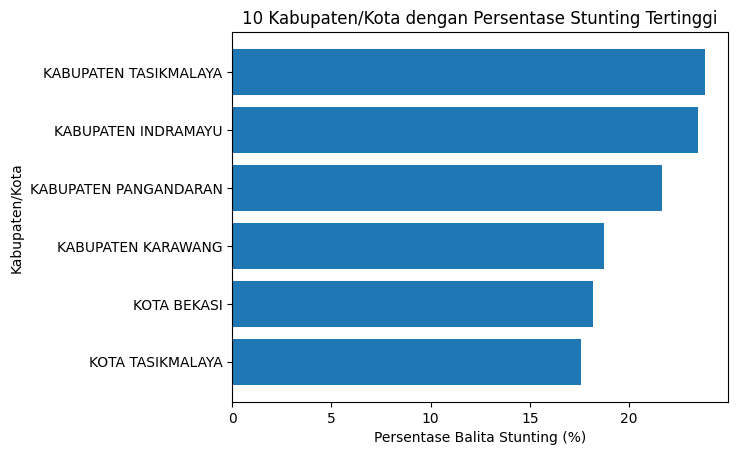

In [11]:
top10 = df.sort_values(by="persentase_balita_stunting", ascending=False).head(10)

plt.figure()
plt.barh(top10["nama_kabupaten_kota"], top10["persentase_balita_stunting"])
plt.xlabel("Persentase Balita Stunting (%)")
plt.ylabel("Kabupaten/Kota")
plt.title("10 Kabupaten/Kota dengan Persentase Stunting Tertinggi")
plt.gca().invert_yaxis()
plt.show()

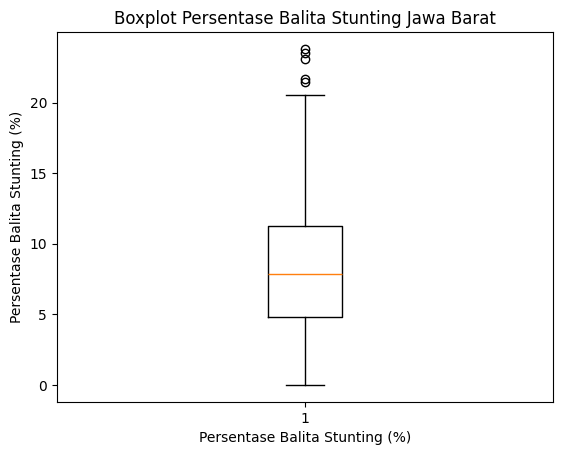

In [12]:
plt.boxplot(df["persentase_balita_stunting"].dropna())
plt.ylabel("Persentase Balita Stunting (%)")
plt.title("Boxplot Persentase Balita Stunting Jawa Barat")
plt.xlabel("Persentase Balita Stunting (%)")
plt.show()

“Deteksi outlier dilakukan menggunakan metode Interquartile Range (IQR), dengan batas bawah dan atas masing-masing sebesar Q1 − 1,5×IQR dan Q3 + 1,5×IQR. Data yang berada di luar rentang tersebut dikategorikan sebagai outlier.”

“Outlier tidak dihapus, tetapi dianalisis sebagai wilayah dengan tingkat stunting ekstrem.”

In [13]:
# cols to normalize
cols_to_normalize = ["persentase_balita_stunting"]

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_normalized = df.copy()

df_normalized[cols_to_normalize] = scaler.fit_transform(df[cols_to_normalize])

df_normalized[["persentase_balita_stunting"]].describe()

,persentase_balita_stunting
count,297.000000
mean,0.347504
std,0.196976
min,0.000000
25%,0.200840
50%,0.328992
75%,0.472689
max,1.000000


Menampilkan data normalisasi paling atas sebanyak 20 baris

In [15]:
df_normalized.head(20)

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,persentase_balita_stunting,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,0.379832,PERSEN,2014
1,2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,0.513025,PERSEN,2014
2,3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,0.602101,PERSEN,2014
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,0.720168,PERSEN,2014
4,5,32,JAWA BARAT,3205,KABUPATEN GARUT,0.299160,PERSEN,2014
5,6,32,JAWA BARAT,3206,KABUPATEN TASIKMALAYA,1.000000,PERSEN,2014
6,7,32,JAWA BARAT,3207,KABUPATEN CIAMIS,0.215126,PERSEN,2014
7,8,32,JAWA BARAT,3208,KABUPATEN KUNINGAN,0.315966,PERSEN,2014
8,9,32,JAWA BARAT,3209,KABUPATEN CIREBON,0.543697,PERSEN,2014
9,10,32,JAWA BARAT,3210,KABUPATEN MAJALENGKA,0.438235,PERSEN,2014


Menampilkan data paling atas sebanyak 20 baris

In [16]:
df.head(20)

,id,kode_provinsi,nama_provinsi,kode_kabupaten_kota,nama_kabupaten_kota,persentase_balita_stunting,satuan,tahun
0,1,32,JAWA BARAT,3201,KABUPATEN BOGOR,9.04,PERSEN,2014
1,2,32,JAWA BARAT,3202,KABUPATEN SUKABUMI,12.21,PERSEN,2014
2,3,32,JAWA BARAT,3203,KABUPATEN CIANJUR,14.33,PERSEN,2014
3,4,32,JAWA BARAT,3204,KABUPATEN BANDUNG,17.14,PERSEN,2014
4,5,32,JAWA BARAT,3205,KABUPATEN GARUT,7.12,PERSEN,2014
5,6,32,JAWA BARAT,3206,KABUPATEN TASIKMALAYA,23.80,PERSEN,2014
6,7,32,JAWA BARAT,3207,KABUPATEN CIAMIS,5.12,PERSEN,2014
7,8,32,JAWA BARAT,3208,KABUPATEN KUNINGAN,7.52,PERSEN,2014
8,9,32,JAWA BARAT,3209,KABUPATEN CIREBON,12.94,PERSEN,2014
9,10,32,JAWA BARAT,3210,KABUPATEN MAJALENGKA,10.43,PERSEN,2014


“Penelitian ini tidak menggunakan Decision Tree Classifier karena tujuan analisis bersifat deskriptif dan tidak melibatkan proses klasifikasi atau prediksi. Fokus penelitian adalah pada analisis sebaran dan perbandingan persentase balita stunting antar wilayah.”

In [17]:
X = df_normalized[["persentase_balita_stunting"]]

kmeans = KMeans(n_clusters=3, random_state=42)
df_normalized["cluster"] = kmeans.fit_predict(X)

df_normalized.groupby("cluster")["persentase_balita_stunting"].mean()

cluster
0    0.36594
1    0.64063
2    0.14898
Name: persentase_balita_stunting, dtype: float64

In [18]:
df_normalized[["nama_kabupaten_kota", "persentase_balita_stunting", "cluster"]].head(20)

,nama_kabupaten_kota,persentase_balita_stunting,cluster
0,KABUPATEN BOGOR,0.379832,0
1,KABUPATEN SUKABUMI,0.513025,1
2,KABUPATEN CIANJUR,0.602101,1
3,KABUPATEN BANDUNG,0.720168,1
4,KABUPATEN GARUT,0.299160,0
5,KABUPATEN TASIKMALAYA,1.000000,1
6,KABUPATEN CIAMIS,0.215126,2
7,KABUPATEN KUNINGAN,0.315966,0
8,KABUPATEN CIREBON,0.543697,1
9,KABUPATEN MAJALENGKA,0.438235,0


“Metode K-Means digunakan sebagai analisis tambahan untuk mengelompokkan kabupaten/kota berdasarkan persentase balita stunting. Pengelompokan dilakukan pada data yang telah dinormalisasi menggunakan metode Min–Max dengan jumlah cluster sebanyak tiga.”

In [19]:
cluster_map = {0: "Sedang", 1: "Tinggi", 2: "Rendah"}

df_normalized["kategori_stunting"] = df_normalized["cluster"].map(cluster_map)
df_normalized[
    ["nama_kabupaten_kota", "persentase_balita_stunting", "kategori_stunting"]
].head(20)

,nama_kabupaten_kota,persentase_balita_stunting,kategori_stunting
0,KABUPATEN BOGOR,0.379832,Sedang
1,KABUPATEN SUKABUMI,0.513025,Tinggi
2,KABUPATEN CIANJUR,0.602101,Tinggi
3,KABUPATEN BANDUNG,0.720168,Tinggi
4,KABUPATEN GARUT,0.299160,Sedang
5,KABUPATEN TASIKMALAYA,1.000000,Tinggi
6,KABUPATEN CIAMIS,0.215126,Rendah
7,KABUPATEN KUNINGAN,0.315966,Sedang
8,KABUPATEN CIREBON,0.543697,Tinggi
9,KABUPATEN MAJALENGKA,0.438235,Sedang


**KMeans Elbow Method**

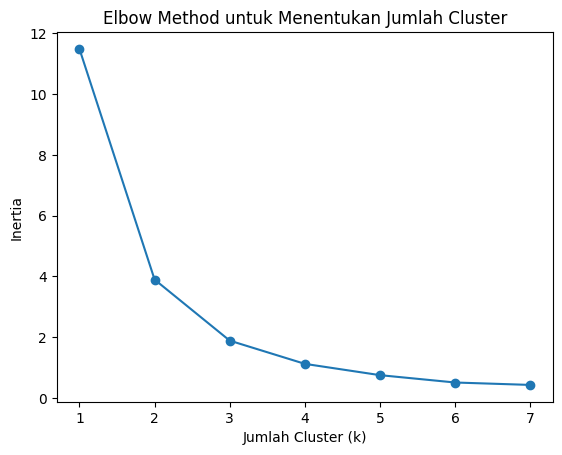

In [20]:
X = df_normalized[["persentase_balita_stunting"]]

inertia = []
K = range(1, 8)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker="o")
plt.xlabel("Jumlah Cluster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan Jumlah Cluster")
plt.show()

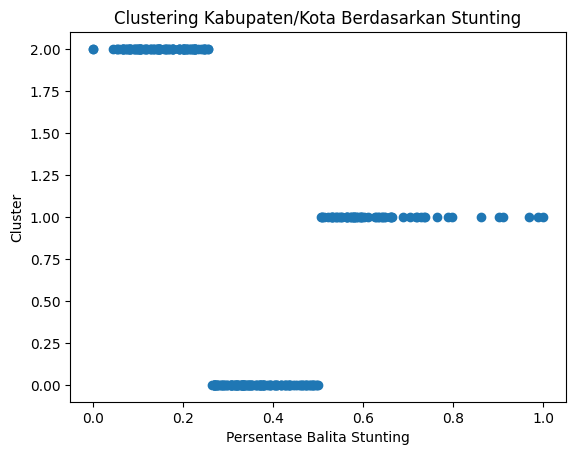

In [21]:
plt.scatter(df_normalized["persentase_balita_stunting"], df_normalized["cluster"])
plt.xlabel("Persentase Balita Stunting")
plt.ylabel("Cluster")
plt.title("Clustering Kabupaten/Kota Berdasarkan Stunting")
plt.show()

“Clustering dilakukan menggunakan metode K-Means dengan jumlah cluster sebanyak tiga berdasarkan hasil Elbow Method. Pengelompokan dilakukan pada data persentase balita stunting yang telah dinormalisasi menggunakan metode Min–Max. Hasil clustering membagi kabupaten/kota ke dalam kelompok stunting rendah, sedang, dan tinggi.”

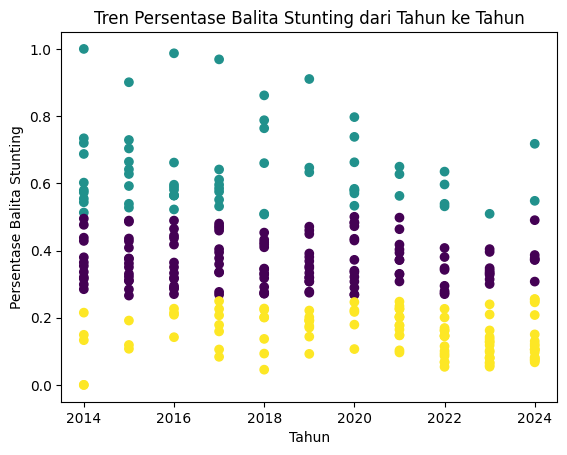

In [22]:
plt.Figure()
plt.scatter(
    df_normalized["tahun"],
    df_normalized["persentase_balita_stunting"],
    c=df_normalized["cluster"],
)
plt.xlabel("Tahun")
plt.ylabel("Persentase Balita Stunting")
plt.title("Tren Persentase Balita Stunting dari Tahun ke Tahun")
plt.show()

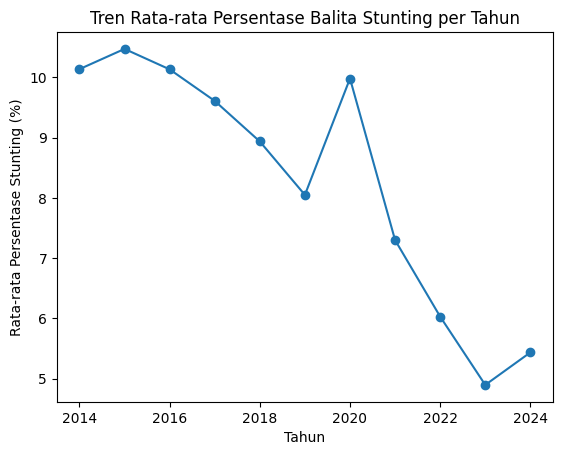

In [23]:
trend_tahun = df.groupby("tahun")["persentase_balita_stunting"].mean()

plt.figure()
plt.plot(trend_tahun.index, trend_tahun.values, marker="o")
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Persentase Stunting (%)")
plt.title("Tren Rata-rata Persentase Balita Stunting per Tahun")
plt.show()

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(df["nama_kabupaten_kota"], df["persentase_balita_stunting"])
plt.xticks(rotation=90)
plt.ylabel("Persentase Stunting (%)")
plt.title("Persentase Balita Stunting per Kabupaten/Kota")
plt.show()

“Melalui penggunaan bar chart, boxplot, dan line chart, visualisasi data mampu memperkuat hasil statistik deskriptif serta memberikan gambaran yang lebih jelas mengenai perbandingan antar wilayah, sebaran data, keberadaan outlier, dan tren stunting antar tahun.”